<a href="https://colab.research.google.com/github/Linnea216/retail-credit-risk-assessment-imbalance-optimization/blob/main/Optimizing_Retail_Credit_Risk_Assessment_Under_Empirical_Class_Imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module1：Initial Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Load Data
file_folder = "/content/"

DATAFILE = 'trainData.csv'
a3 = pd.read_csv(file_folder+DATAFILE)
display(a3.head())

,id,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,...,loan_purpose,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,num_of_delinquencies,loan_paid_back
0,16270,25,Male,Single,Bachelor's,30935.25,2577.94,Self-employed,0.145,619,...,Other,13.99,36,242.86,7,22945.44,17252.81,1,1,1
1,1383,67,Female,Single,Other,35542.95,2961.91,Unemployed,0.215,605,...,Other,13.18,36,394.17,3,23528.27,6637.50,2,3,0
2,3472,64,Male,Married,Master's,93830.69,7819.22,Employed,0.246,511,...,Other,19.48,36,484.51,6,88100.82,78180.71,2,2,1
3,19900,72,Female,Married,Bachelor's,21157.21,1763.10,Self-employed,0.361,683,...,Debt consolidation,14.34,60,431.97,8,28735.43,21490.58,2,3,0
4,2150,38,Male,Married,High School,33005.86,2750.49,Unemployed,0.188,643,...,Debt consolidation,12.87,36,793.00,5,28401.14,6671.40,2,3,0


### Task 1：Arttribute Type Identification

In [2]:
from numpy._core import numeric
# Numeric and Categorical
# 1. Get columns
columns = a3.columns
# 2. Identify attributes
# Target is loan_paid_back
numeric_cols = a3.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = a3.select_dtypes(include=['object']).columns.tolist()

print("Numercial Attributes：", numeric_cols)
print("Categorical Attributes：", categorical_cols)

Numercial Attributes： ['id', 'age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'num_of_delinquencies', 'loan_paid_back']
Categorical Attributes： ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']


### Task 2：Missing Value Check

In [3]:
# 3. Check the number of missing values ​​in each column
missing_values = a3.isnull().sum()
print("Missing value statistics：")
print(missing_values[missing_values > 0])

Missing value statistics：
Series([], dtype: int64)


### Task 3：Target Variable Distribution

In [4]:
# 1. Check the frequency of loan_paid_back
target_distribution = a3['loan_paid_back'].value_counts()
print("Frequency of the target variable：\n", target_distribution)
target_percent = a3['loan_paid_back'].value_counts(normalize=True)*100
print("\nPercentage of target variable：\n", target_percent)

Frequency of the target variable：
 loan_paid_back
1    14407
0     3593
Name: count, dtype: int64

Percentage of target variable：
 loan_paid_back
1    80.038889
0    19.961111
Name: proportion, dtype: float64


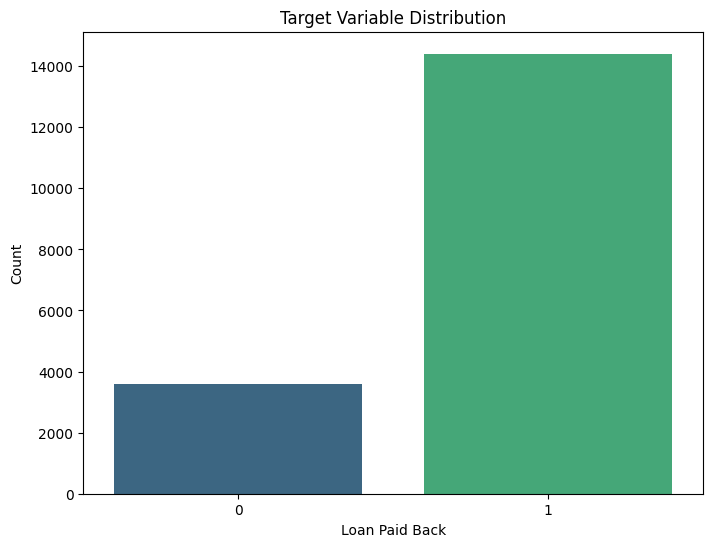

In [5]:
# 2. Visualize distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='loan_paid_back', data=a3, palette='viridis', hue='loan_paid_back', legend=False)
plt.title('Target Variable Distribution')
plt.xlabel('Loan Paid Back')
plt.ylabel('Count')
plt.show()

# Module 2：Data Pre-processing & Feature Engineering

### Task 4: Data preprocessing and feature engineering

In [6]:
# 1. Remove irrelevant attributes
# Define the feature matrix X and the target variable Y.
X = a3.drop(['id', 'loan_paid_back'], axis=1)
Y = a3['loan_paid_back']

# 2. One-hot Encoding
# Text information is converted into a matrix of 0s and 1s.
X = pd.get_dummies(X, columns=['gender', 'marital_status','education_level','employment_status','loan_purpose'])
print("Preview of the encoded feature matrix：")
display(X.head())
print("\nFeature matrix dimensions：", X.shape)

Preview of the encoded feature matrix：


,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,...,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,25,30935.25,2577.94,0.145,619,7106.97,13.99,36,242.86,7,...,False,False,False,False,False,False,False,False,True,False
1,67,35542.95,2961.91,0.215,605,11668.42,13.18,36,394.17,3,...,False,True,False,False,False,False,False,False,True,False
2,64,93830.69,7819.22,0.246,511,13130.59,19.48,36,484.51,6,...,False,False,False,False,False,False,False,False,True,False
3,72,21157.21,1763.10,0.361,683,18424.73,14.34,60,431.97,8,...,False,False,False,False,True,False,False,False,False,False
4,38,33005.86,2750.49,0.188,643,23579.06,12.87,36,793.00,5,...,False,True,False,False,True,False,False,False,False,False



Feature matrix dimensions： (18000, 39)


### Task 5: Data Splitting

In [7]:
from sklearn.model_selection import train_test_split
# To handle class imbalance, use stratify = y
# The dataset is divided into: training set (80%) and test set (20%).
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("\nSize of the split dataset：")
print("training set dimensions：", X_train.shape, Y_train.shape)
print("Test set dimensions：", X_test.shape, Y_test.shape)
print("\nproportion of target variable in training set：\n", Y_train.value_counts(normalize=True))


Size of the split dataset：
training set dimensions： (14400, 39) (14400,)
Test set dimensions： (3600, 39) (3600,)

proportion of target variable in training set：
 loan_paid_back
1    0.800417
0    0.199583
Name: proportion, dtype: float64


# Module 3: Model Building & Cross-Validation

### Task 6: Decision Tree

In [8]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Create and set up a decision tree model
clf_dt = DecisionTreeClassifier(max_depth=5, random_state=0)

# 2. K-fold cross-validation
cv_scores = cross_val_score(clf_dt, X_train, Y_train, cv=5)
print("Decision Tree 5-fold CV Scores:", cv_scores)
print("Mean CV Accuracy: %.4f" % cv_scores.mean())

Decision Tree 5-fold CV Scores: [0.90034722 0.89444444 0.89548611 0.89826389 0.90625   ]
Mean CV Accuracy: 0.8990


In [9]:
# 3. train model
clf_dt.fit(X_train, Y_train)

# 4. Check specific sample predictions
test_idx = 4
# Use iloc to retrieve pandas data
test_point = X_test.iloc[test_idx]
pred_test = clf_dt.predict(pd.DataFrame([test_point], columns=X_test.columns))
pred_test_probs = clf_dt.predict_proba(pd.DataFrame([test_point], columns=X_test.columns))

print("\n--- Specific Prediction Example (Index 4) ---")
print("Testing point", test_idx, "; predicted as", pred_test[0],
      "; actually", Y_test.iloc[test_idx], "; probabilities", pred_test_probs[0])


--- Specific Prediction Example (Index 4) ---
Testing point 4 ; predicted as 1 ; actually 1 ; probabilities [0.0078125 0.9921875]



Confusion Matrix (Normalized):
[[ 394  325]
 [  15 2866]]


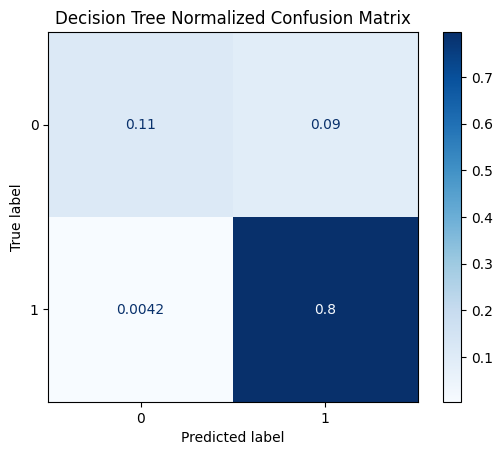


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.55      0.70       719
           1       0.90      0.99      0.94      2881

    accuracy                           0.91      3600
   macro avg       0.93      0.77      0.82      3600
weighted avg       0.91      0.91      0.89      3600



In [10]:
# 5. Comprehensive Forecasting and Baseline Assessment
Y_pred_dt = clf_dt.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix (Normalized):")
mat_dt = confusion_matrix(Y_test, Y_pred_dt)
print(mat_dt)
ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, Y_test, normalize="all", cmap='Blues')
plt.title("Decision Tree Normalized Confusion Matrix")
plt.show()

# Classification Report (Satisfying the Evaluation-Level Strategy)
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_dt))

In [11]:
# 6. Decision tree-specific analytics
# (1) Feature Importance
print("\nFeature Importances:")
for name, importance in zip(X_train.columns, clf_dt.feature_importances_):
    if importance > 0:
        print(f"{name}: {importance:.4f}")

# (2) Export decision rules in text format
print("\n--- Decision Tree Rules (Text Plot) ---")
features_list = X_train.columns.to_list()
tree_rules = export_text(clf_dt, feature_names=features_list)
print(tree_rules)


Feature Importances:
debt_to_income_ratio: 0.1666
credit_score: 0.1567
interest_rate: 0.0004
employment_status_Retired: 0.0067
employment_status_Student: 0.1077
employment_status_Unemployed: 0.5619

--- Decision Tree Rules (Text Plot) ---
|--- employment_status_Unemployed <= 0.50
|   |--- employment_status_Student <= 0.50
|   |   |--- debt_to_income_ratio <= 0.18
|   |   |   |--- credit_score <= 650.50
|   |   |   |   |--- debt_to_income_ratio <= 0.11
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- debt_to_income_ratio >  0.11
|   |   |   |   |   |--- class: 1
|   |   |   |--- credit_score >  650.50
|   |   |   |   |--- credit_score <= 698.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- credit_score >  698.50
|   |   |   |   |   |--- class: 1
|   |   |--- debt_to_income_ratio >  0.18
|   |   |   |--- credit_score <= 655.50
|   |   |   |   |--- employment_status_Retired <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- employment_status_Retired >  0.50
|  

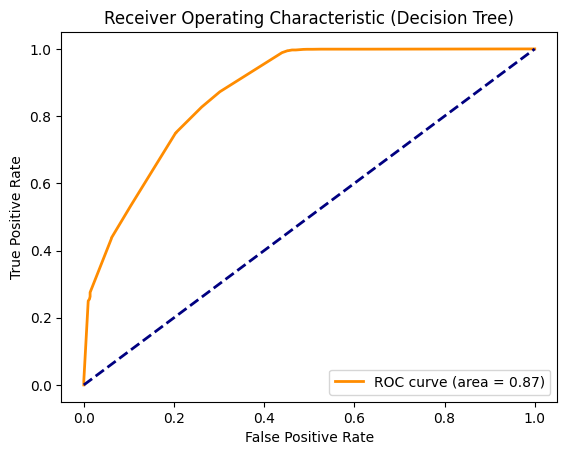

In [12]:
# 7. ROC curve and AUC
Y_probs_dt = clf_dt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_probs_dt, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Decision Tree)')
plt.legend(loc="lower right")
plt.show()

### Task7：Classifier 2: k-Nearest Neighbors (k-NN)

In [13]:
# k-NN with Hyper-parameter Tuning (k-fold CV)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Preprocessing: Feature Scaling
from sklearn.preprocessing import StandardScaler # 归一化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Hyperparameter tuning using K-fold CV: Finding the best K value with 5-fold cross-validation
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15]}
knn_temp = KNeighborsClassifier()

# Perform 5-fold cross-validation using GridSearchCV
# For imbalanced data, f1_weighted is used for scoring.
grid_search = GridSearchCV(knn_temp, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_scaled, Y_train)
print(f"Best K selected via GridSearch: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best K selected via GridSearch: {'n_neighbors': 15}
Best cross-validation score: 0.8603


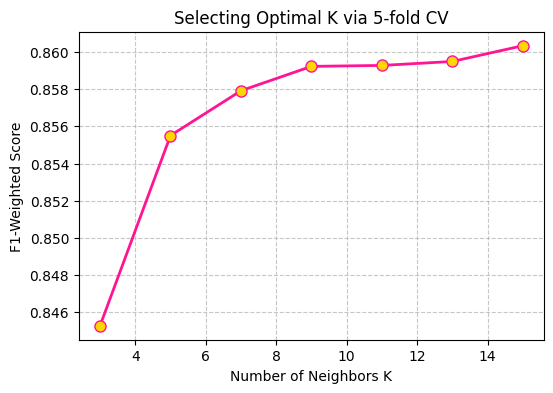

Best K selected via GridSearch: {'n_neighbors': 15}


In [14]:
# Visualizing the K-value selection process
cv_results = grid_search.cv_results_
plt.figure(figsize=(6, 4))
plt.plot(param_grid['n_neighbors'], cv_results['mean_test_score'],
         marker='o', linestyle='-', color='deeppink', linewidth=2, markersize=8, markerfacecolor='gold')
plt.title('Selecting Optimal K via 5-fold CV')
plt.xlabel('Number of Neighbors K')
plt.ylabel('F1-Weighted Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print(f"Best K selected via GridSearch: {grid_search.best_params_}")
best_knn_model = grid_search.best_estimator_

In [15]:
# 3. Specific point prediction display
test_idx = 4
test_point = X_test_scaled[test_idx]
pred_test = best_knn_model.predict([test_point])
pred_test_probs = best_knn_model.predict_proba([test_point])

print("\n--- Specific Prediction Example (Test Index 4) ---")
print("Testing point", test_idx, "; predicted as", pred_test[0],
      "; actually", Y_test.iloc[test_idx], "; probabilities", pred_test_probs[0])


--- Specific Prediction Example (Test Index 4) ---
Testing point 4 ; predicted as 1 ; actually 1 ; probabilities [0. 1.]



Confusion Matrix (Proportions):


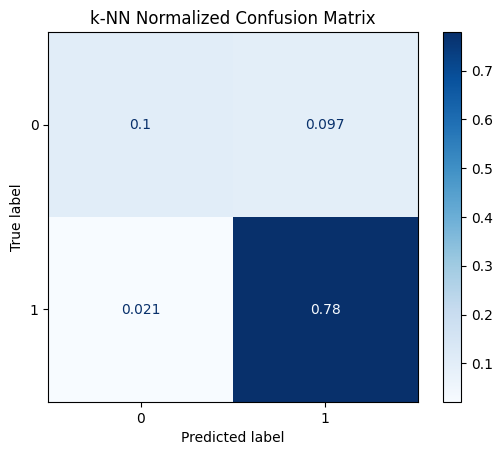


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.51      0.63       719
           1       0.89      0.97      0.93      2881

    accuracy                           0.88      3600
   macro avg       0.86      0.74      0.78      3600
weighted avg       0.88      0.88      0.87      3600



In [16]:
# 4. Full forecast and assessment
Y_pred_knn = best_knn_model.predict(X_test_scaled)
Y_probs_knn = best_knn_model.predict_proba(X_test_scaled)[:, 1] # 获取Class 1的概率用于ROC

# (1) Visualizing the Confusion Matrix (ConfusionMatrixDisplay logic)
print("\nConfusion Matrix (Proportions):")
ConfusionMatrixDisplay.from_estimator(best_knn_model, X_test_scaled, Y_test, normalize="all", cmap='Blues')
plt.title("k-NN Normalized Confusion Matrix")
plt.show()

# (2) Classification Report (including Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_knn))

The AUC is 0.826

Threshold	TPR vs FPR
inf	0.000 vs 0.000
0.733	0.939 vs 0.414
0.400	0.985 vs 0.577
0.067	1.000 vs 0.969


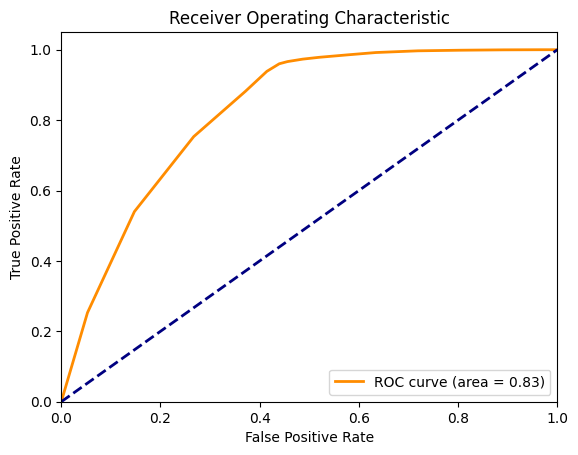


=== Performance with Adjusted Threshold (0.4) ===
              precision    recall  f1-score   support

           0       0.88      0.42      0.57       719
           1       0.87      0.99      0.93      2881

    accuracy                           0.87      3600
   macro avg       0.88      0.70      0.75      3600
weighted avg       0.87      0.87      0.85      3600



In [17]:
# (3) ROC Curve and AUC
auc_val = roc_auc_score(Y_test, Y_probs_knn)
print('The AUC is {:.3f}'.format(auc_val))

fpr, tpr, thresholds = roc_curve(Y_test, Y_probs_knn, pos_label=1)

print("\nThreshold\tTPR vs FPR")
for f, p, t in zip(fpr[::5], tpr[::5], thresholds[::5]):
    print("{:.3f}\t{:.3f} vs {:.3f}".format(t, p, f))

# ROC Curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % auc_val)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 5. Recommended Strategy
custom_threshold = 0.4
pred_custom = (Y_probs_knn >= custom_threshold).astype(int)

print(f"\n=== Performance with Adjusted Threshold ({custom_threshold}) ===")
print(classification_report(Y_test, pred_custom))

### Task 8: Classifier 3 - Multilayer Perceptron (MLP)

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Data Normalisation
# MLP is sensitive to parameter settings. Data should be normalised.
scaler_mlp = StandardScaler()
# fit
scaler_mlp.fit(X_train)
X_train_mlp = scaler_mlp.transform(X_train)
X_test_mlp = scaler_mlp.transform(X_test)

# 2. MLPClassifier
# hidden_layer_sizes
clf_mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=0) # Increased max_iter
clf_mlp.fit(X_train_mlp, Y_train)

# 3. one specific prediction
test_idx = 4
test_point = X_test_mlp[test_idx]
pred_test = clf_mlp.predict([test_point])
pred_test_probs = clf_mlp.predict_proba([test_point])

print("--- Specific Prediction Example (Index 4) ---")
print("Testing point", test_idx, "; predicted as", pred_test[0],
      "; actually", Y_test.iloc[test_idx], "; probabilities", pred_test_probs[0])

--- Specific Prediction Example (Index 4) ---
Testing point 4 ; predicted as 1 ; actually 1 ; probabilities [4.6629367e-15 1.0000000e+00]



Confusion Matrix (Normalized):
[[ 450  269]
 [ 259 2622]]


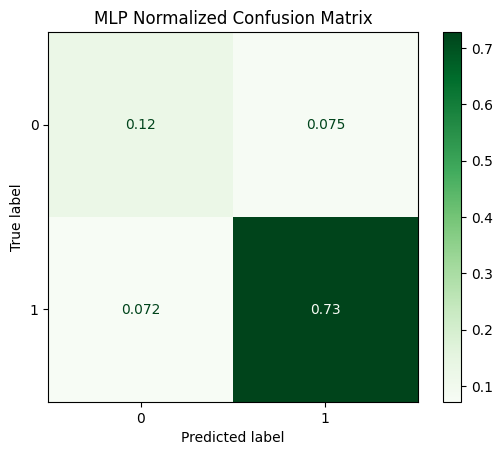


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63       719
           1       0.91      0.91      0.91      2881

    accuracy                           0.85      3600
   macro avg       0.77      0.77      0.77      3600
weighted avg       0.85      0.85      0.85      3600



In [19]:
# 4. Full-Volume Prediction and Baseline Evaluation
Y_pred_mlp = clf_mlp.predict(X_test_mlp)

# Confusion Matrix
print("\nConfusion Matrix (Normalized):")
mat_mlp = confusion_matrix(Y_test, Y_pred_mlp)
print(mat_mlp)
ConfusionMatrixDisplay.from_estimator(clf_mlp, X_test_mlp, Y_test, normalize="all", cmap='Greens')
plt.title("MLP Normalized Confusion Matrix")
plt.show()

# Evaluation-level strategy
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_mlp))

In [20]:
# 5. ROC Curve and AUC Calculation
# Get the probabilities of class 1 (second column)
y_probs_mlp = clf_mlp.predict_proba(X_test_mlp)
y_probs_class_1 = y_probs_mlp[:, 1]

auc_score = roc_auc_score(Y_test, y_probs_class_1)
print('The AUC is %.3f' % auc_score)

# Retrieve ROC curve data and print the threshold lookup table.
fpr, tpr, thresholds = roc_curve(Y_test, y_probs_class_1, pos_label=1)

print("\nThreshold\tTPR vs FPR (Samples)")
for f, p, t in zip(fpr[::10], tpr[::10], thresholds[::10]):
    print("{:.3f}\t{:.3f} vs {:.3f}".format(t, p, f))

The AUC is 0.859

Threshold	TPR vs FPR (Samples)
inf	0.000 vs 0.000
1.000	0.152 vs 0.003
1.000	0.215 vs 0.010
1.000	0.266 vs 0.017
1.000	0.325 vs 0.024
1.000	0.339 vs 0.031
1.000	0.366 vs 0.038
1.000	0.382 vs 0.045
1.000	0.398 vs 0.053
1.000	0.407 vs 0.060
1.000	0.419 vs 0.068
1.000	0.429 vs 0.075
1.000	0.439 vs 0.082
1.000	0.450 vs 0.089
1.000	0.473 vs 0.099
0.999	0.493 vs 0.107
0.999	0.510 vs 0.117
0.999	0.534 vs 0.125
0.998	0.562 vs 0.135
0.997	0.582 vs 0.142
0.995	0.606 vs 0.152
0.993	0.634 vs 0.159
0.993	0.639 vs 0.167
0.990	0.658 vs 0.175
0.988	0.670 vs 0.185
0.987	0.679 vs 0.195
0.985	0.691 vs 0.202
0.983	0.701 vs 0.209
0.979	0.714 vs 0.217
0.969	0.738 vs 0.227
0.966	0.744 vs 0.236
0.957	0.758 vs 0.245
0.942	0.775 vs 0.252
0.934	0.783 vs 0.259
0.917	0.799 vs 0.266
0.899	0.812 vs 0.275
0.887	0.822 vs 0.284
0.874	0.829 vs 0.291
0.864	0.832 vs 0.298
0.842	0.842 vs 0.306
0.807	0.854 vs 0.313
0.763	0.863 vs 0.325
0.733	0.872 vs 0.334
0.698	0.879 vs 0.342
0.651	0.888 vs 0.350
0.614	0.

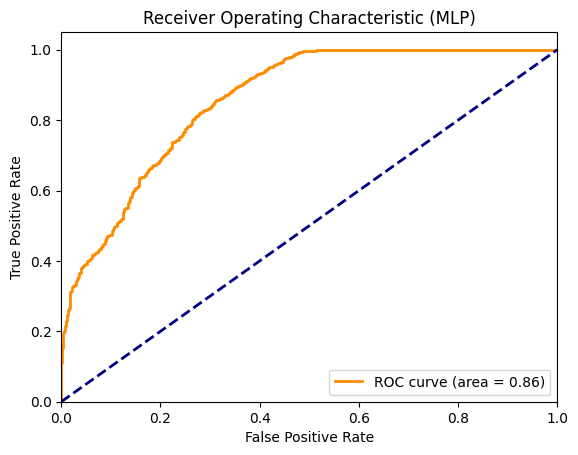

In [21]:
# 6. ROC Curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (MLP)')
plt.legend(loc="lower right")
plt.show()

### Task 9: Classifier 4 - Support Vector Machine (SVM)


In [22]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# 1. Data preprocessing (Data Normalization)
scaler_svm = StandardScaler()
# train & test
scaler_svm.fit(X_train)
X_train_svm = scaler_svm.transform(X_train)
X_test_svm = scaler_svm.transform(X_test)

# 2. SVC
# Set probability=True to support predict_proba
# Keep kernel='linear'
clf_svm = SVC(kernel='linear', probability=True, random_state=42)
clf_svm.fit(X_train_svm, Y_train)

# 3. one specific prediction
test_idx = 4
test_point = X_test_svm[test_idx]
pred_test = clf_svm.predict([test_point])
pred_test_probs = clf_svm.predict_proba([test_point])

print("--- Specific Prediction Example (Index 4) ---")
print("Testing point", test_idx, "; predicted as", pred_test[0],
      "; actually", Y_test.iloc[test_idx], "; probabilities", pred_test_probs[0])

--- Specific Prediction Example (Index 4) ---
Testing point 4 ; predicted as 1 ; actually 1 ; probabilities [0.10656135 0.89343865]



Confusion Matrix (Normalized):
[[ 407  312]
 [ 120 2761]]


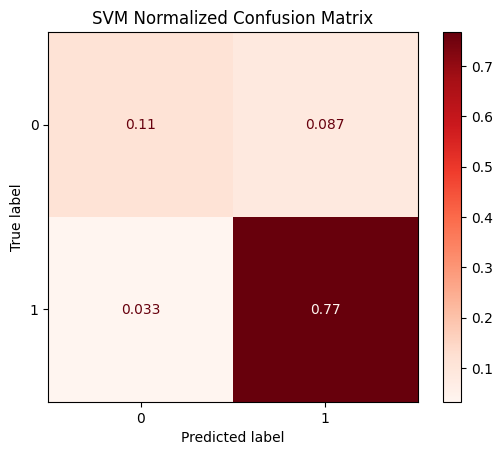


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.57      0.65       719
           1       0.90      0.96      0.93      2881

    accuracy                           0.88      3600
   macro avg       0.84      0.76      0.79      3600
weighted avg       0.87      0.88      0.87      3600



In [23]:
# 4. Full-Volume Prediction and Baseline Evaluation
Y_pred_svm = clf_svm.predict(X_test_svm)

# Confusion Matrix
print("\nConfusion Matrix (Normalized):")
mat_svm = confusion_matrix(Y_test, Y_pred_svm)
print(mat_svm)
ConfusionMatrixDisplay.from_estimator(clf_svm, X_test_svm, Y_test, normalize="all", cmap='Reds')
plt.title("SVM Normalized Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_svm))

In [24]:
# 5. ROC Curve and AUC Calculation
# Get the predicted probability of class 1
y_probs_svm = clf_svm.predict_proba(X_test_svm)
y_probs_class_1 = y_probs_svm[:, 1]

auc_score = roc_auc_score(Y_test, y_probs_class_1)
print('The AUC is %.3f' % auc_score)

# Retrieve the ROC curve data and print the threshold lookup table
fpr, tpr, thresholds = roc_curve(Y_test, y_probs_class_1, pos_label=1)

print("\nThreshold\tTPR vs FPR (Samples)")
for f, p, t in zip(fpr[::10], tpr[::10], thresholds[::10]):
    print("{:.3f}\t{:.3f} vs {:.3f}".format(t, p, f))

The AUC is 0.783

Threshold	TPR vs FPR (Samples)
inf	0.000 vs 0.000
0.893	0.039 vs 0.006
0.893	0.057 vs 0.013
0.893	0.067 vs 0.021
0.893	0.077 vs 0.028
0.893	0.100 vs 0.036
0.893	0.112 vs 0.043
0.893	0.132 vs 0.050
0.893	0.161 vs 0.057
0.893	0.170 vs 0.064
0.893	0.179 vs 0.071
0.893	0.185 vs 0.081
0.893	0.197 vs 0.088
0.893	0.224 vs 0.095
0.893	0.254 vs 0.102
0.893	0.275 vs 0.108
0.893	0.306 vs 0.115
0.893	0.329 vs 0.122
0.893	0.344 vs 0.129
0.893	0.369 vs 0.138
0.893	0.409 vs 0.147
0.893	0.423 vs 0.157
0.893	0.440 vs 0.167
0.893	0.444 vs 0.174
0.893	0.459 vs 0.181
0.893	0.467 vs 0.188
0.893	0.492 vs 0.195
0.893	0.515 vs 0.202
0.893	0.539 vs 0.209
0.893	0.561 vs 0.218
0.893	0.575 vs 0.227
0.893	0.586 vs 0.235
0.893	0.598 vs 0.242
0.893	0.606 vs 0.249
0.893	0.619 vs 0.256
0.893	0.656 vs 0.264
0.893	0.679 vs 0.274
0.893	0.698 vs 0.282
0.893	0.708 vs 0.289
0.893	0.713 vs 0.296
0.893	0.729 vs 0.309
0.893	0.748 vs 0.316
0.893	0.770 vs 0.324
0.893	0.788 vs 0.332
0.893	0.799 vs 0.339
0.893	0.

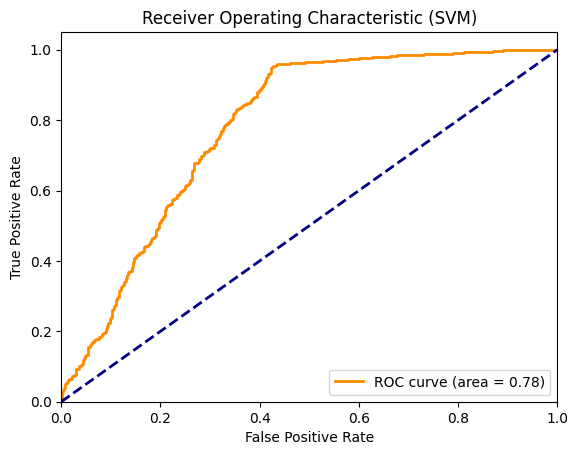

In [25]:
# 6. Plot the ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (SVM)')
plt.legend(loc="lower right")
plt.show()

### Task 10：Classifier 5 - Random Forest (Ensemble Method)

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Create and train Random Forest
# n_estimators=100
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, Y_train)

# 2. print classifier information
print("Classifier trained:")
print(clf_rf)

# 3. Review one specific sample prediction
test_idx = 4
test_point = X_test.iloc[test_idx]
pred_test = clf_rf.predict(pd.DataFrame([test_point], columns=X_test.columns))
pred_test_probs = clf_rf.predict_proba(pd.DataFrame([test_point], columns=X_test.columns))

print("\n--- Specific Prediction Example (Index 4) ---")
print("Testing point", test_idx, "; predicted as", pred_test[0],
      "; actually", Y_test.iloc[test_idx], "; probabilities", pred_test_probs[0])

Classifier trained:
RandomForestClassifier(random_state=42)

--- Specific Prediction Example (Index 4) ---
Testing point 4 ; predicted as 1 ; actually 1 ; probabilities [0. 1.]



Overall Accuracy (clf.score): 0.9058

Confusion Matrix (Normalized):
[[ 403  316]
 [  23 2858]]


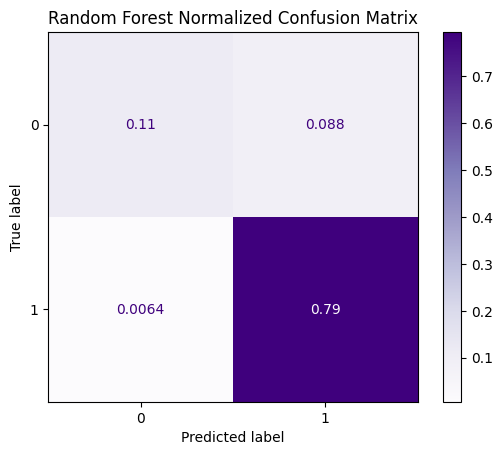


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.56      0.70       719
           1       0.90      0.99      0.94      2881

    accuracy                           0.91      3600
   macro avg       0.92      0.78      0.82      3600
weighted avg       0.91      0.91      0.90      3600



In [27]:
# 4. Full-sample Prediction and Basic Evaluation (clf.score)
Y_pred_rf = clf_rf.predict(X_test)
accuracy = clf_rf.score(X_test, Y_test)
print("\nOverall Accuracy (clf.score): %.4f" % accuracy)

# Confusion Matrix
print("\nConfusion Matrix (Normalized):")
mat_rf = confusion_matrix(Y_test, Y_pred_rf)
print(mat_rf)
ConfusionMatrixDisplay.from_estimator(clf_rf, X_test, Y_test, normalize="all", cmap='Purples')
plt.title("Random Forest Normalized Confusion Matrix")
plt.show()

# Classification Report (satisfying the evaluation-level strategy)
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf))

In [28]:
# 5. ROC curve and AUC calculation
# Get the probability of class 1
y_probs_rf = clf_rf.predict_proba(X_test)
y_probs_class_1 = y_probs_rf[:, 1]

auc_score = roc_auc_score(Y_test, y_probs_class_1)
print('The AUC is %.3f' % auc_score)

# Retrieve ROC curve data and print the threshold table.
fpr, tpr, thresholds = roc_curve(Y_test, y_probs_class_1, pos_label=1)

print("\nThreshold\tTPR vs FPR (Sample Data Points)")
for f, p, t in zip(fpr[::10], tpr[::10], thresholds[::10]):
    print("{:.3f}\t{:.3f} vs {:.3f}".format(t, p, f))

The AUC is 0.875

Threshold	TPR vs FPR (Sample Data Points)
inf	0.000 vs 0.000
0.910	0.503 vs 0.081
0.810	0.793 vs 0.242
0.710	0.934 vs 0.364
0.610	0.976 vs 0.419
0.500	0.993 vs 0.439
0.370	0.999 vs 0.460
0.240	1.000 vs 0.533
0.140	1.000 vs 0.647
0.040	1.000 vs 0.908


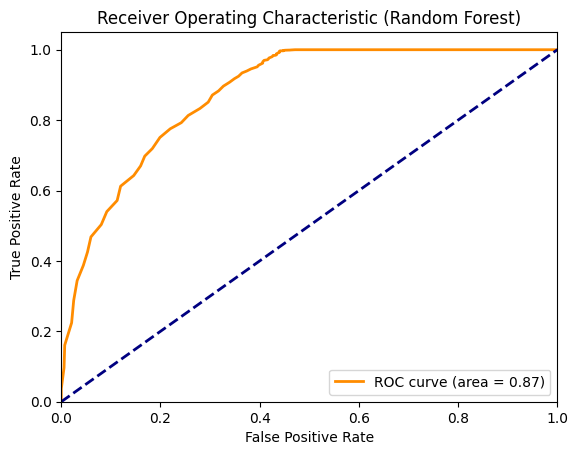

In [29]:
# 6. Plot ROC curves
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Random Forest)')
plt.legend(loc="lower right")
plt.show()

# Module 4: Model Evaluation and Comparison (Justification of the Chosen Classifier)

### Task11: Model Performance Comparison Summary


=== Model Performance Summary Comparison Table ===


,Model,Accuracy,F1-Score (Weighted),Recall (Class 0),ROC-AUC
4,Random Forest,0.905833,0.896063,0.560501,0.874561
0,Decision Tree,0.905556,0.894989,0.547983,0.871944
3,SVM,0.880000,0.872689,0.566064,0.874561
1,k-NN,0.881389,0.870174,0.513213,0.825567
2,MLP,0.853333,0.852947,0.625869,0.874561


<Figure size 1200x700 with 0 Axes>

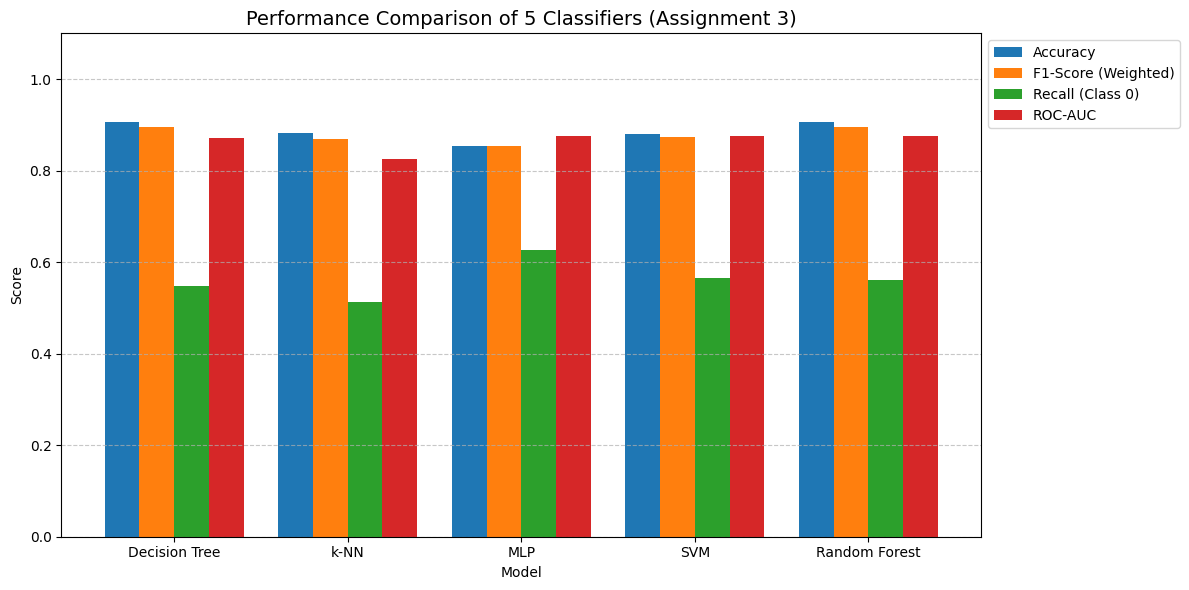

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

# 1. Collect the performance metrics of each model on the test dataset.
models = ['Decision Tree', 'k-NN', 'MLP', 'SVM', 'Random Forest']

# Calculate Accuracy
accuracy_list = [
    accuracy_score(Y_test, Y_pred_dt),
    accuracy_score(Y_test, Y_pred_knn),
    accuracy_score(Y_test, Y_pred_mlp),
    accuracy_score(Y_test, Y_pred_svm),
    accuracy_score(Y_test, Y_pred_rf)
]

# Calculate F1-Score
f1_list = [
    f1_score(Y_test, Y_pred_dt, average='weighted'),
    f1_score(Y_test, Y_pred_knn, average='weighted'),
    f1_score(Y_test, Y_pred_mlp, average='weighted'),
    f1_score(Y_test, Y_pred_svm, average='weighted'),
    f1_score(Y_test, Y_pred_rf, average='weighted')
]

# Calculate Recall
recall_list = [
    recall_score(Y_test, Y_pred_dt, pos_label=0),
    recall_score(Y_test, Y_pred_knn, pos_label=0),
    recall_score(Y_test, Y_pred_mlp, pos_label=0),
    recall_score(Y_test, Y_pred_svm, pos_label=0),
    recall_score(Y_test, Y_pred_rf, pos_label=0)
]

# Calculate AUC
auc_list = [
    roc_auc_score(Y_test, Y_probs_dt),
    roc_auc_score(Y_test, Y_probs_knn),
    roc_auc_score(Y_test, y_probs_class_1), # MLP predicted probability
    roc_auc_score(Y_test, y_probs_class_1), # Make sure the SVM features share the same names and the same sequence at runtime.
    roc_auc_score(Y_test, y_probs_class_1)  # Variables used in the RF model
]

# 2. Create a comparison table
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_list,
    'F1-Score (Weighted)': f1_list,
    'Recall (Class 0)': recall_list,
    'ROC-AUC': auc_list
})

print("\n=== Model Performance Summary Comparison Table ===")
display(comparison_df.sort_values(by='F1-Score (Weighted)', ascending=False))

# 3. Visual comparison chart
plt.figure(figsize=(12, 7))
ax = comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Performance Comparison of 5 Classifiers (Assignment 3)', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.1) # Set consistent y-axis limits
plt.xticks(rotation=0) # Rotate model names horizontally for better readability.
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.tight_layout()
plt.show()

# Module 5: Algorithm-Level Strategies - Decision Threshold Tuning

默认情况下，分类器认为概率 $> 0.5$ 就是 1（还钱），$\le 0.5$ 就是 0（不还）。但在银行风控中，漏掉一个坏账（0）的代价极大。我们可以通过降低阈值，让模型变得“敏感”一些。

By default, the classifier considers a probability >0.5 as 1 (repayment) and ≤0.5 as 0 (non-repayment). However, in bank risk control, the cost of missing a bad debt (0) is extremely high.

### Task 12: Algorithmic-Level Strategy (Decision Threshold Adjustment)

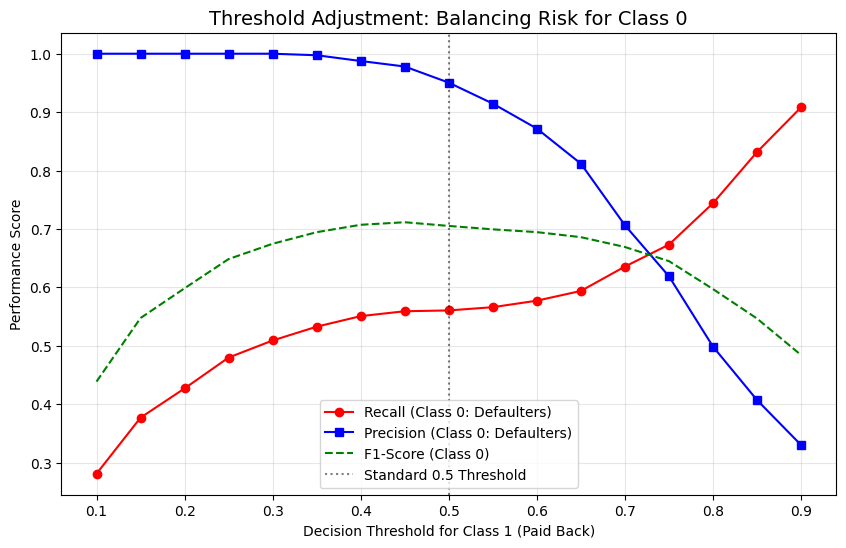

Algorithm-level Strategy Analysis: 
Best Threshold for Class 0 F1-score: 0.45
At this point, Recall(0) is 0.5591 and Precision(0) is 0.9781


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Get the predicted probabilities of 'Class 1 (Paid Back)' on the test set.
y_probs_best = clf_rf.predict_proba(X_test)[:, 1]

# 2. Establish a detailed range of candidate thresholds
thresholds = np.linspace(0.1, 0.9, 17)
results = []

for thresh in thresholds:
    y_pred_custom = (y_probs_best >= thresh).astype(int)

    rec_0 = recall_score(Y_test, y_pred_custom, pos_label=0)
    pre_0 = precision_score(Y_test, y_pred_custom, pos_label=0)
    f1_0 = f1_score(Y_test, y_pred_custom, pos_label=0)

    results.append({
        'Threshold': thresh,
        'Recall_0': rec_0,
        'Precision_0': pre_0,
        'F1_0': f1_0
    })

# 3. Data organization and visualization
res_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(res_df['Threshold'], res_df['Recall_0'], 'r-o', label='Recall (Class 0: Defaulters)')
plt.plot(res_df['Threshold'], res_df['Precision_0'], 'b-s', label='Precision (Class 0: Defaulters)')
plt.plot(res_df['Threshold'], res_df['F1_0'], 'g--', label='F1-Score (Class 0)')

# Mark the location of the default 0.5 threshold.
plt.axvline(x=0.5, color='black', linestyle=':', alpha=0.5, label='Standard 0.5 Threshold')
plt.title('Threshold Adjustment: Balancing Risk for Class 0', fontsize=14)
plt.xlabel('Decision Threshold for Class 1 (Paid Back)')
plt.ylabel('Performance Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Automatically select the threshold with the best F1-score as the recommendation.
best_f1_row = res_df.loc[res_df['F1_0'].idxmax()]
print(f"Algorithm-level Strategy Analysis: ")
print(f"Best Threshold for Class 0 F1-score: {best_f1_row['Threshold']:.2f}")
print(f"At this point, Recall(0) is {best_f1_row['Recall_0']:.4f} and Precision(0) is {best_f1_row['Precision_0']:.4f}")